# Laboratorio #6 - NLP

1. Conceptos básicos
### ¿Qué es el Spam y el Ham?
En el mundo de la computación, clasificamos los mensajes principalmente en dos grupos:
- Ham: Son los mensajes "buenos" o legítimos. Es todo lo que sí queremos recibir, como un mensaje de un amigo, un correo del trabajo o una notificación que sí pedimos.
- Spam: Es el correo basura. Son mensajes que no solicitamos y que se envían de forma masiva. Generalmente buscan publicidad engañosa, estafas o simplemente saturar nuestra bandeja de entrada.

### ¿Por qué es importante separarlos?
No se trata solo de que el spam sea molesto; es un problema de seguridad y eficiencia. Implementar filtros automáticos nos ayuda a:
- Ahorrar tiempo: No perdemos minutos revisando publicidad basura para encontrar un mensaje importante.
- Mejorar la seguridad: Evitamos que los usuarios caigan en estafas de phishing o descarguen archivos dañinos.
- Organizar datos: En una empresa, ayuda a mantener los canales de comunicación limpios y confiables.
### ¿Cómo funciona la clasificación automática?
Para que una computadora decida si un mensaje es basura o no, usamos modelos de probabilidad. El método más clásico es el clasificador Naive Bayes.
Básicamente, este algoritmo analiza las palabras que aparecen en el mensaje y calcula qué tan probable es que pertenezca a una categoría u otra basándose en ejemplos previos. Matemáticamente, usamos el Teorema de Bayes para esta estimación:
$$P(\text{clase} \mid \text{texto}) \propto P(\text{clase}) \cdot \prod_{i} P(w_i \mid \text{clase})$$
Sin embargo, el algoritmo no puede leer el texto directamente como nosotros. Primero necesitamos limpiar los datos: quitar signos de puntuación, pasar todo a minúsculas y simplificar las palabras. Ese proceso de preprocesamiento es justamente lo que vamos a trabajar en esta práctica.

Wikipedia contributors. (2025, November 18). Naive Bayes spam filtering. Wikipedia. https://en.wikipedia.org/wiki/Naive_Bayes_spam_filtering

---
## 2. Carga y Exploración de Datos (EDA)

In [22]:
# --- Importaciones ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import re
import string
from collections import Counter
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
PALETTE = {'ham': '#2196F3', 'spam': '#F44336'}

print('Librerías cargadas correctamente ✓')

Librerías cargadas correctamente ✓


In [23]:
# --- Carga del dataset ---
df = pd.read_csv('spam_ham.csv', encoding='latin-1', sep=';')

# Limpiar etiquetas con caracteres extra
df['Label'] = df['Label'].str.strip().str.replace('"', '', regex=False)
df = df[df['Label'].isin(['ham', 'spam'])].copy()
df['SMS_TEXT'] = df['SMS_TEXT'].fillna('').astype(str)

print(f'Filas totales: {len(df)}')
print(f'Columnas: {df.columns.tolist()}')
df.head(3)

Filas totales: 5565
Columnas: ['Label', 'SMS_TEXT']


,Label,SMS_TEXT
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...


In [24]:
# --- 5 mensajes aleatorios ---
print('=== 5 mensajes aleatorios ===')
sample = df.sample(5, random_state=42)[['Label', 'SMS_TEXT']]
for _, row in sample.iterrows():
    tag = 'SPAM' if row['Label'] == 'spam' else 'HAM '
    print(f"{tag} | {row['SMS_TEXT'][:120]}")
    print()

=== 5 mensajes aleatorios ===
HAM  | Yup i thk they r e teacher said that will make my face look longer. Darren ask me not 2 cut too short.

SPAM | Your weekly Cool-Mob tones are ready to download !This weeks new Tones include: 1) Crazy Frog-AXEL F>>> 2) Akon-Lonely>>

HAM  | Die... Now i have e toot fringe again...

HAM  | Just curious because my cuz asked what I was up to

HAM  | Hope you are not scared!



=== Cantidad de mensajes ===
  HAM :  4819  (86.6%)
  SPAM:   746  (13.4%)
  TOTAL: 5565


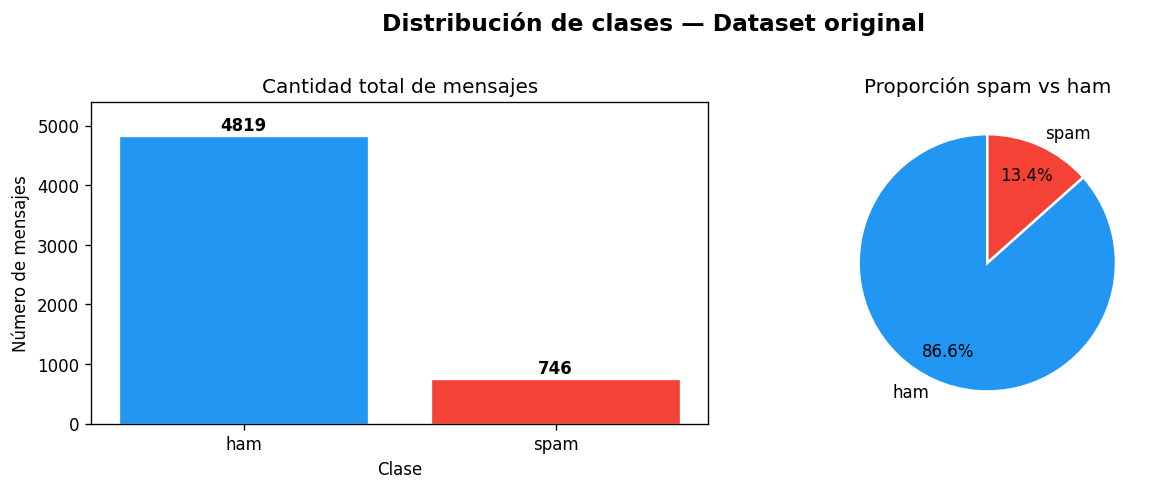

In [25]:
# --- Cantidad total y distribución ---
counts = df['Label'].value_counts()
props  = df['Label'].value_counts(normalize=True) * 100

print('=== Cantidad de mensajes ===')
for lbl in ['ham', 'spam']:
    print(f"  {lbl.upper():4s}: {counts[lbl]:5d}  ({props[lbl]:.1f}%)")
print(f"  TOTAL: {len(df)}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Distribución de clases — Dataset original', fontsize=14, fontweight='bold', y=1.01)

# Barras
bars = axes[0].bar(counts.index, counts.values,
                   color=[PALETTE[l] for l in counts.index],
                   edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 str(val), ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Cantidad total de mensajes')
axes[0].set_ylabel('Número de mensajes')
axes[0].set_xlabel('Clase')
axes[0].set_ylim(0, counts.max() * 1.12)

# Pastel
wedge_colors = [PALETTE[l] for l in counts.index]
axes[1].pie(counts.values, labels=counts.index,
            autopct='%1.1f%%', colors=wedge_colors,
            startangle=90, pctdistance=0.75,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Proporción spam vs ham')

plt.tight_layout()
plt.show()

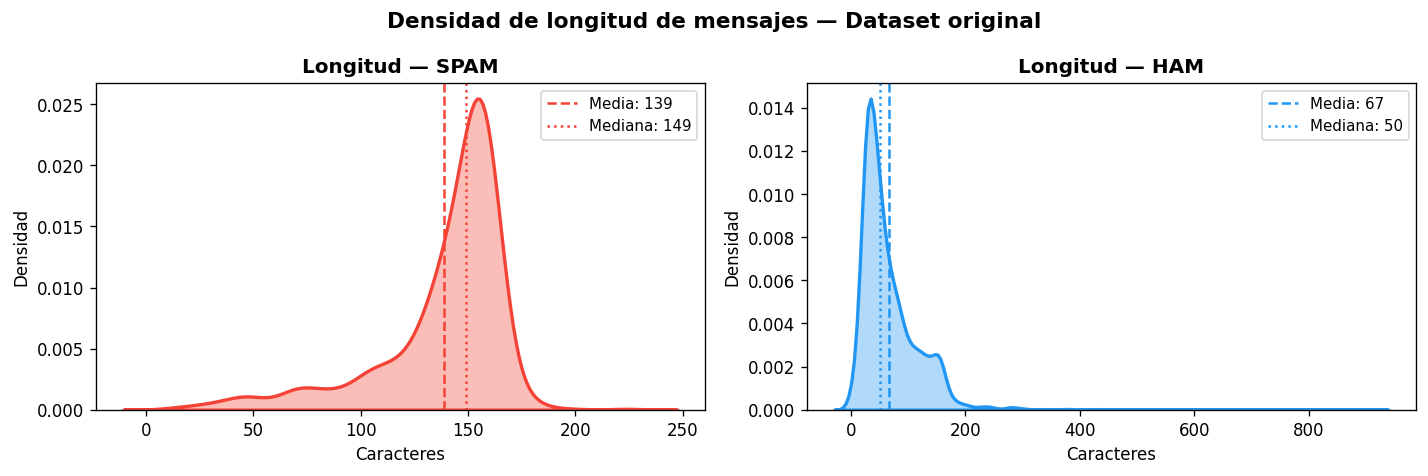

Estadísticas de longitud:
        count   mean   std   min    25%    50%    75%    max
Label                                                       
ham    4819.0   66.9  52.6   0.0   32.0   50.0   87.0  910.0
spam    746.0  138.7  29.5  13.0  132.2  149.0  157.0  224.0


In [26]:
# --- Densidad de longitud de mensajes ---
df['msg_len'] = df['SMS_TEXT'].str.len()

spam_len = df[df['Label'] == 'spam']['msg_len']
ham_len  = df[df['Label'] == 'ham']['msg_len']

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
fig.suptitle('Densidad de longitud de mensajes — Dataset original',
             fontsize=13, fontweight='bold')

for ax, data, label, color in [
        (axes[0], spam_len, 'SPAM', PALETTE['spam']),
        (axes[1], ham_len,  'HAM',  PALETTE['ham'])]:
    sns.kdeplot(data, ax=ax, color=color, fill=True, alpha=0.35, linewidth=2)
    ax.axvline(data.mean(),  color=color, linestyle='--', linewidth=1.5,
               label=f'Media: {data.mean():.0f}')
    ax.axvline(data.median(), color=color, linestyle=':',  linewidth=1.5,
               label=f'Mediana: {data.median():.0f}')
    ax.set_title(f'Longitud — {label}', fontweight='bold')
    ax.set_xlabel('Caracteres')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"Estadísticas de longitud:")
print(df.groupby('Label')['msg_len'].describe().round(1))

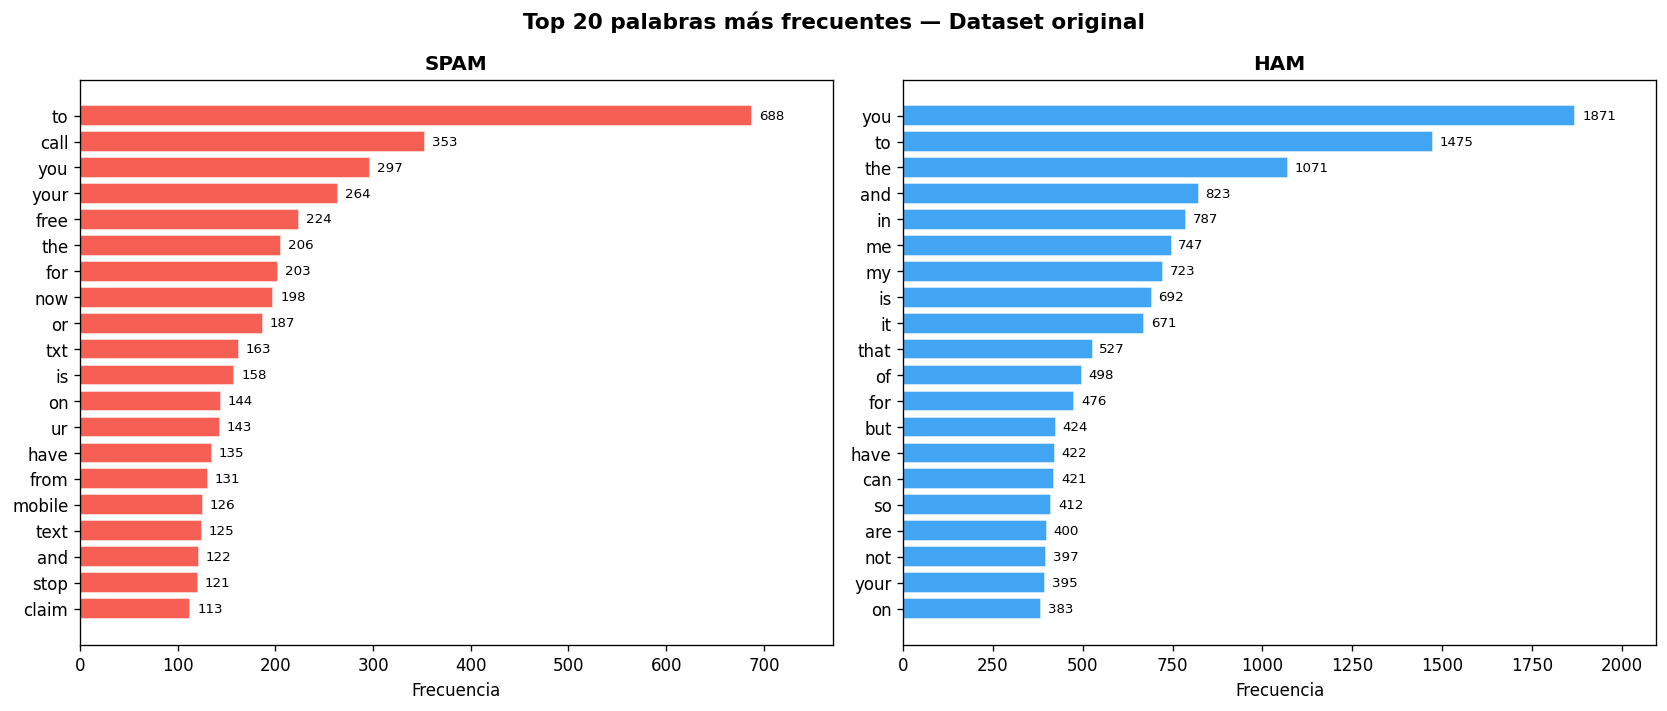

In [27]:
# --- Top 20 palabras más frecuentes (raw) ---
def top_words_raw(texts, n=20):
    all_words = []
    for txt in texts:
        tokens = re.findall(r'\b[a-zA-Z]{2,}\b', txt.lower())
        all_words.extend(tokens)
    return Counter(all_words).most_common(n)

spam_words = top_words_raw(df[df['Label']=='spam']['SMS_TEXT'])
ham_words  = top_words_raw(df[df['Label']=='ham']['SMS_TEXT'])

def plot_top_words(word_list, title, color, ax):
    words, freqs = zip(*word_list)
    bars = ax.barh(words[::-1], freqs[::-1], color=color, alpha=0.85, edgecolor='white')
    for bar, freq in zip(bars, freqs[::-1]):
        ax.text(bar.get_width() + max(freqs)*0.01, bar.get_y() + bar.get_height()/2,
                str(freq), va='center', fontsize=8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Frecuencia')
    ax.set_xlim(0, max(freqs) * 1.12)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Top 20 palabras más frecuentes — Dataset original', fontsize=13, fontweight='bold')
plot_top_words(spam_words, 'SPAM', PALETTE['spam'], axes[0])
plot_top_words(ham_words,  'HAM',  PALETTE['ham'],  axes[1])
plt.tight_layout()
plt.show()

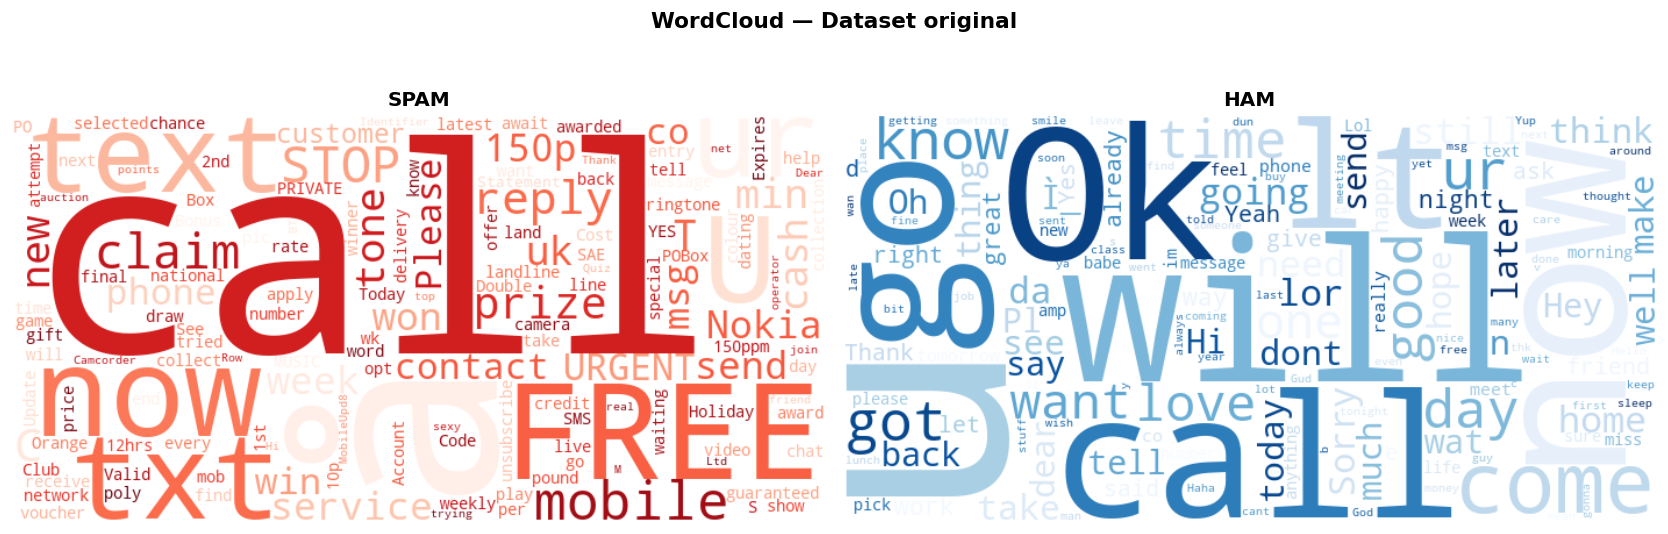

In [28]:
# --- WordCloud (dataset original) ---
def make_wordcloud(texts, title, colormap):
    text_blob = ' '.join(texts)
    wc = WordCloud(width=700, height=350,
                   background_color='white',
                   colormap=colormap,
                   max_words=150,
                   collocations=False).generate(text_blob)
    return wc

wc_spam = make_wordcloud(df[df['Label']=='spam']['SMS_TEXT'], 'SPAM', 'Reds')
wc_ham  = make_wordcloud(df[df['Label']=='ham']['SMS_TEXT'],  'HAM',  'Blues')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('WordCloud — Dataset original', fontsize=13, fontweight='bold')

for ax, wc, title in [(axes[0], wc_spam, 'SPAM'), (axes[1], wc_ham, 'HAM')]:
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

---
## 3. Preprocesamiento de texto con NLTK

El preprocesamiento convierte texto crudo en una representación limpia y normalizada, indispensable para que los modelos de clasificación sean más precisos. A continuación se aplican cinco transformaciones en orden lógico:

In [29]:
# Verificar stopwords de NLTK
STOP_WORDS = set(stopwords.words('english'))
print(f'Stopwords en inglés cargadas: {len(STOP_WORDS)}')
print('Muestra:', list(STOP_WORDS)[:15])

Stopwords en inglés cargadas: 198
Muestra: ['which', 'or', 'are', "i'd", 'by', 'wasn', "she'll", 'been', 'on', "shan't", 'all', 'while', 'than', 'shan', 'needn']


### Paso 1: Tokenización

**¿En qué consiste?** Es el proceso de dividir el texto completo en piezas más pequeñas llamadas *tokens* (que normalmente son palabras sueltas). En este caso, usamos expresiones regulares para quedarnos solo con las letras, dejando fuera los números o símbolos raros que no aportan mucho significado.

**¿Para qué sirve?** Las computadoras no pueden analizar un bloque de texto así como viene; necesitan que los datos estén estructurados. Al tokenizar, definimos qué palabras va a "conocer" nuestro modelo y nos aseguramos de trabajar solo con la información que realmente nos sirve para el análisis.

### Paso 2: Conversión a minúsculas

**¿En qué consiste?** Básicamente, se trata de pasar todo el texto a minúsculas para que no haya distinciones por el uso de mayúsculas.

**¿Para qué sirve?** Para una computadora, las palabras "OFRETA", "Oferta" y "oferta" son cadenas de texto totalmente diferentes. Si no las normalizamos, el modelo tendría que aprender tres veces lo mismo, lo que hace que el vocabulario crezca innecesariamente y el entrenamiento sea menos eficiente. Al convertir todo a minúsculas, unificamos los términos y nos aseguramos de que el modelo reconozca la palabra sin importar cómo esté escrita.

### Paso 3: Eliminación de signos de puntuación

**¿En qué consiste?** Se encarga de limpiar el texto de cualquier carácter que no sea una letra o un espacio, como puntos, comas, signos de interrogación o paréntesis.

**¿Para qué sirve?** En la mayoría de los casos, la puntuación no nos dice mucho sobre si un mensaje es spam o no, así que termina siendo "ruido" que estorba al modelo. Al quitarlos, simplificamos el vocabulario y estandarizamos el formato. Es importante mencionar que, aunque en análisis de sentimientos un signo de exclamación puede dar pistas sobre una emoción, para este tipo de clasificación preferimos priorizar la limpieza del texto.

### Paso 4: Eliminación de *stopwords*

**¿En qué consiste?** Se trata de filtrar y borrar las palabras que más se repiten en un idioma pero que no dicen mucho por sí solas, como los artículos (*el*, *la*), las preposiciones (*en*, *de*) o los pronombres (*yo*, *tú*).

**¿Para qué sirve?** Estas palabras aparecen en casi cualquier mensaje, ya sea spam o legítimo, por lo que no ayudan a diferenciarlos. Al quitarlas, logramos que el modelo se concentre en las palabras que realmente tienen "peso" y contenido relevante para la clasificación, como *gratis*, *premio* o *urgente*.

### Paso 5: Stemming con PorterStemmer

**¿En qué consiste?** Básicamente, es recortar las palabras para quedarnos solo con su raíz o base (*stem*), quitando sufijos y terminaciones. Por ejemplo, palabras como *corriendo*, *correr* o *corrió* se reducirían a una misma raíz. Usamos el **PorterStemmer**, que aplica reglas automáticas para hacer estos recortes (como transformar *prizes* en *prize* o *calling* en *call*).

**¿Por qué usamos stemming y no lemmatización?**
Aunque la lemmatización es más precisa porque usa un diccionario real, requiere descargar archivos pesados que no siempre tenemos disponibles en un laboratorio sin internet. El **PorterStemmer** es mucho más ligero porque usa reglas lógicas y no necesita consultar bases de datos externas. Para un modelo como Naive Bayes, ambos métodos funcionan de forma similar: el objetivo es que el algoritmo entienda que distintas versiones de una palabra son en realidad la misma idea, reduciendo así la complejidad de los datos.

In [30]:
# --- Pipeline de preprocesamiento ---
stemmer = PorterStemmer()

def preprocess(text: str) -> str:
    """
    Aplica el pipeline completo de preprocesamiento NLP:
    1. Tokenización (regex sobre letras)
    2. Minúsculas
    3. Eliminación de puntuación (implícita por el regex)
    4. Eliminación de stopwords
    5. Stemming (PorterStemmer)
    """
    # 1. Tokenizar y 2. minúsculas simultáneamente
    tokens = re.findall(r'\b[a-zA-Z]{2,}\b', text.lower())   # paso 1 + 2 + 3
    # 4. Eliminar stopwords
    tokens = [t for t in tokens if t not in STOP_WORDS]
    # 5. Stemming
    tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)

# Ejemplo ilustrativo del pipeline
ejemplo = "FREE entry in 2 a wkly competition to win FA Cup Final tickets!! Text 'FA' to 87121"
print('=== Ejemplo de preprocesamiento ===')
print(f'Original : {ejemplo}')
print(f'Procesado: {preprocess(ejemplo)}')

=== Ejemplo de preprocesamiento ===
Original : FREE entry in 2 a wkly competition to win FA Cup Final tickets!! Text 'FA' to 87121
Procesado: free entri wkli competit win fa cup final ticket text fa


In [31]:
# --- Aplicar a todo el dataset ---
df['clean_text'] = df['SMS_TEXT'].apply(preprocess)
df['clean_len']  = df['clean_text'].str.split().str.len()

print('Preprocesamiento completado ✓')
print(f'\nEjemplos (primeras 3 filas):')
for _, row in df.head(3).iterrows():
    print(f"  [{row['Label'].upper()}]")
    print(f"    Original : {row['SMS_TEXT'][:80]}")
    print(f"    Procesado: {row['clean_text'][:80]}")
    print()

Preprocesamiento completado ✓

Ejemplos (primeras 3 filas):
  [HAM]
    Original : Go until jurong point, crazy.. Available only in bugis n great world la e buffet
    Procesado: go jurong point crazi avail bugi great world la buffet cine got amor wat

  [HAM]
    Original : Ok lar... Joking wif u oni...
    Procesado: ok lar joke wif oni

  [SPAM]
    Original : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 8
    Procesado: free entri wkli comp win fa cup final tkt may text fa receiv entri question std 



---
## 4. Análisis posterior al preprocesamiento

Cantidad de mensajes por clase (no cambia tras preprocesar):
  HAM :  4819  (86.6%)
  SPAM:   746  (13.4%)


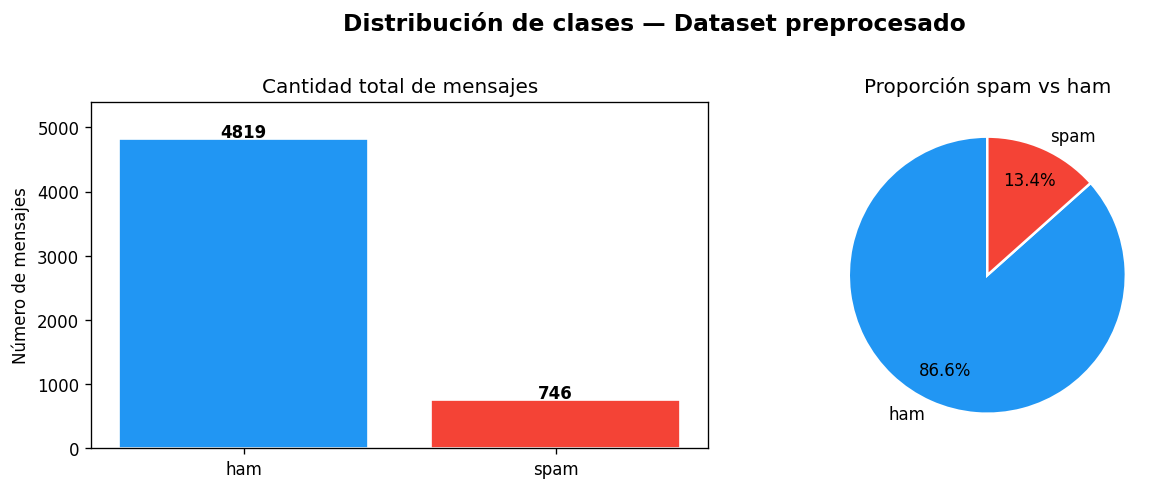

In [32]:
# --- Cantidad y proporción (post) ---
counts_post = df['Label'].value_counts()
print('Cantidad de mensajes por clase (no cambia tras preprocesar):')
for lbl in ['ham', 'spam']:
    p = counts_post[lbl] / len(df) * 100
    print(f'  {lbl.upper():4s}: {counts_post[lbl]:5d}  ({p:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Distribución de clases — Dataset preprocesado', fontsize=14, fontweight='bold', y=1.01)

bars = axes[0].bar(counts_post.index, counts_post.values,
                   color=[PALETTE[l] for l in counts_post.index],
                   edgecolor='white')
for bar, val in zip(bars, counts_post.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 str(val), ha='center', fontweight='bold')
axes[0].set_title('Cantidad total de mensajes')
axes[0].set_ylabel('Número de mensajes')
axes[0].set_ylim(0, counts_post.max() * 1.12)

axes[1].pie(counts_post.values, labels=counts_post.index,
            autopct='%1.1f%%', colors=[PALETTE[l] for l in counts_post.index],
            startangle=90, pctdistance=0.75,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Proporción spam vs ham')

plt.tight_layout()
plt.show()

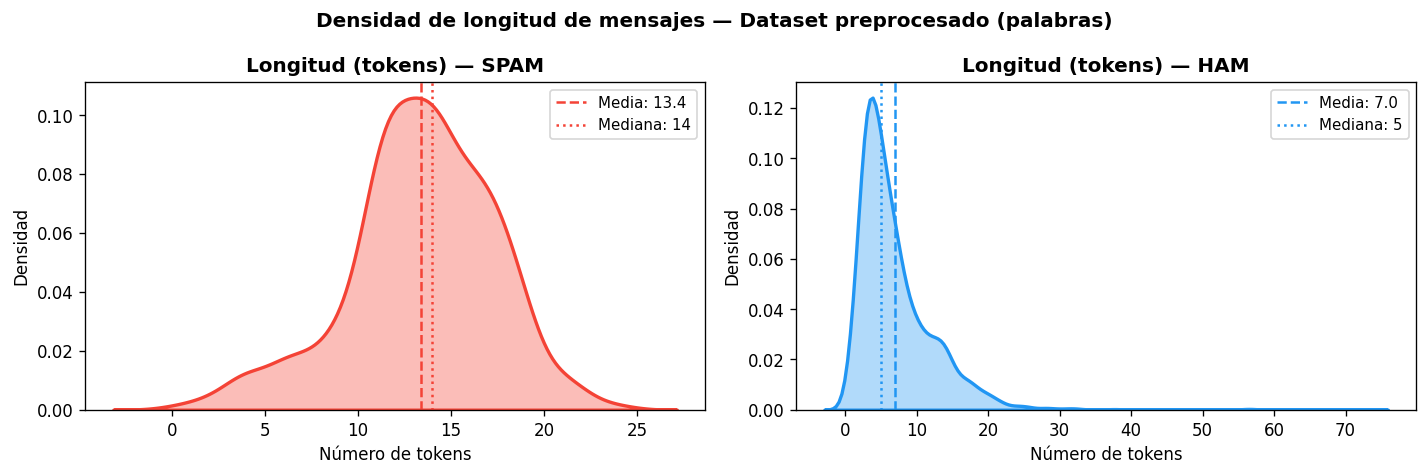

Estadísticas de longitud (tokens) tras preprocesamiento:
        count  mean  std  min   25%   50%   75%   max
Label                                                
ham    4819.0   7.0  5.3  0.0   3.0   5.0   9.0  73.0
spam    746.0  13.4  3.9  0.0  11.0  14.0  16.0  24.0


In [33]:
# --- Densidad de longitud (post) — en palabras, no caracteres ---
spam_clen = df[df['Label']=='spam']['clean_len']
ham_clen  = df[df['Label']=='ham']['clean_len']

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
fig.suptitle('Densidad de longitud de mensajes — Dataset preprocesado (palabras)',
             fontsize=12, fontweight='bold')

for ax, data, label, color in [
        (axes[0], spam_clen, 'SPAM', PALETTE['spam']),
        (axes[1], ham_clen,  'HAM',  PALETTE['ham'])]:
    sns.kdeplot(data, ax=ax, color=color, fill=True, alpha=0.35, linewidth=2)
    ax.axvline(data.mean(),   color=color, linestyle='--', linewidth=1.5,
               label=f'Media: {data.mean():.1f}')
    ax.axvline(data.median(), color=color, linestyle=':',  linewidth=1.5,
               label=f'Mediana: {data.median():.0f}')
    ax.set_title(f'Longitud (tokens) — {label}', fontweight='bold')
    ax.set_xlabel('Número de tokens')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print('Estadísticas de longitud (tokens) tras preprocesamiento:')
print(df.groupby('Label')['clean_len'].describe().round(1))

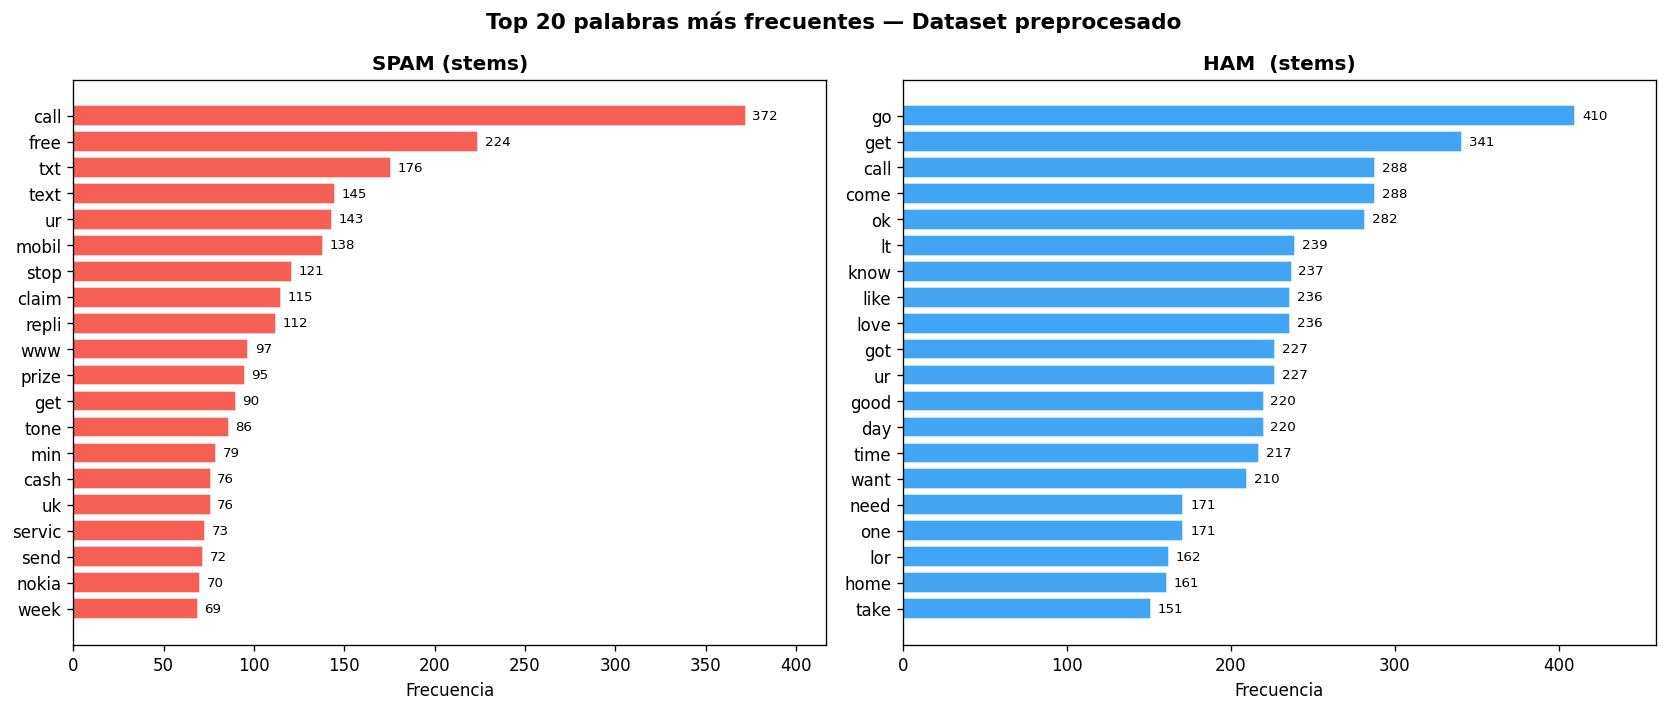

In [34]:
# --- Top 20 palabras post-preprocesamiento ---
def top_words_clean(texts, n=20):
    all_words = []
    for txt in texts:
        all_words.extend(txt.split())
    return Counter(all_words).most_common(n)

spam_clean_words = top_words_clean(df[df['Label']=='spam']['clean_text'])
ham_clean_words  = top_words_clean(df[df['Label']=='ham']['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Top 20 palabras más frecuentes — Dataset preprocesado',
             fontsize=13, fontweight='bold')
plot_top_words(spam_clean_words, 'SPAM (stems)', PALETTE['spam'], axes[0])
plot_top_words(ham_clean_words,  'HAM  (stems)', PALETTE['ham'],  axes[1])
plt.tight_layout()
plt.show()

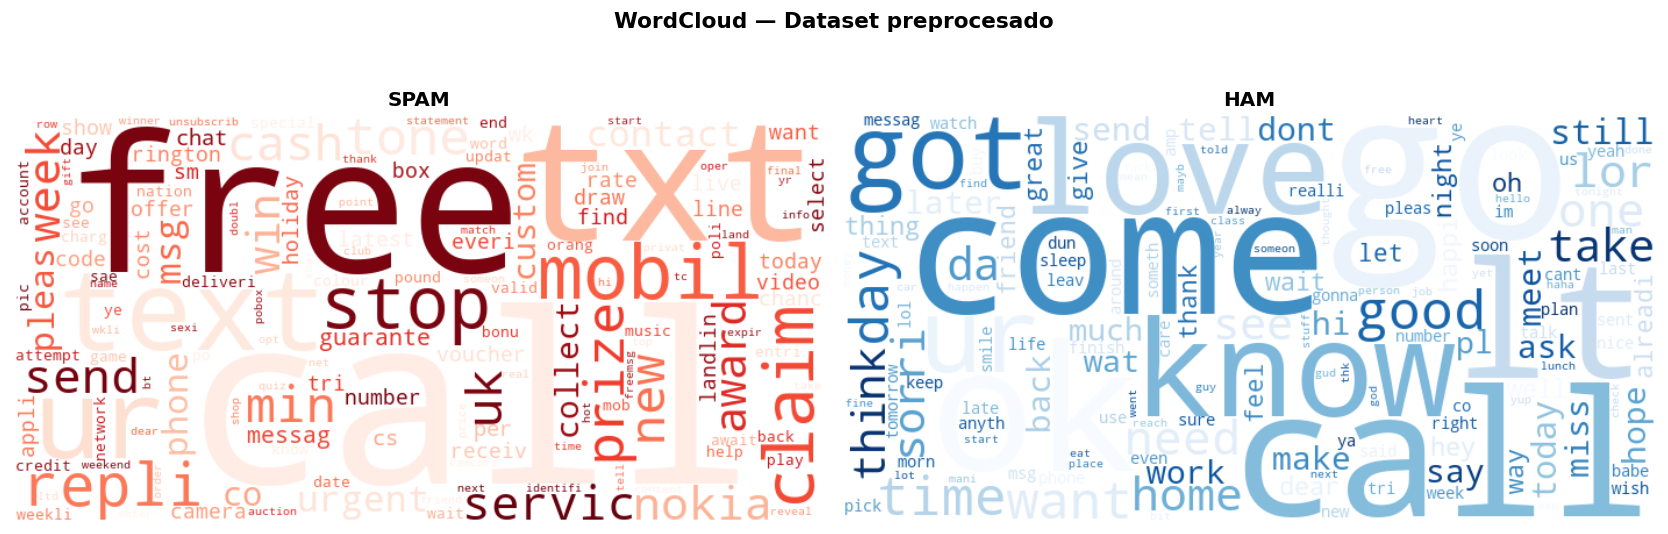

In [35]:
# --- WordCloud post-preprocesamiento ---
wc_spam_c = make_wordcloud(df[df['Label']=='spam']['clean_text'], 'SPAM', 'Reds')
wc_ham_c  = make_wordcloud(df[df['Label']=='ham']['clean_text'],  'HAM',  'Blues')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('WordCloud — Dataset preprocesado', fontsize=13, fontweight='bold')
for ax, wc, title in [(axes[0], wc_spam_c, 'SPAM'), (axes[1], wc_ham_c, 'HAM')]:
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

---
## 5. Reflexión y análisis

In [36]:
# --- Comparación vocabulario antes vs después ---
vocab_spam_raw   = set(re.findall(r'\b[a-zA-Z]{2,}\b',
                                  ' '.join(df[df['Label']=='spam']['SMS_TEXT']).lower()))
vocab_spam_clean = set(' '.join(df[df['Label']=='spam']['clean_text']).split())

vocab_ham_raw    = set(re.findall(r'\b[a-zA-Z]{2,}\b',
                                  ' '.join(df[df['Label']=='ham']['SMS_TEXT']).lower()))
vocab_ham_clean  = set(' '.join(df[df['Label']=='ham']['clean_text']).split())

print('=== Reducción de vocabulario por clase ===')
print(f"  SPAM — Raw: {len(vocab_spam_raw):5d}  →  Clean: {len(vocab_spam_clean):5d}  "
      f"(−{100*(1-len(vocab_spam_clean)/len(vocab_spam_raw)):.0f}%)")
print(f"  HAM  — Raw: {len(vocab_ham_raw):5d}  →  Clean: {len(vocab_ham_clean):5d}  "
      f"(−{100*(1-len(vocab_ham_clean)/len(vocab_ham_raw)):.0f}%)")
print()

# Palabras comunes y exclusivas en el Top-20
top20_spam = {w for w, _ in spam_clean_words}
top20_ham  = {w for w, _ in ham_clean_words}

comunes   = top20_spam & top20_ham
excl_spam = top20_spam - top20_ham
excl_ham  = top20_ham  - top20_spam

print('=== Top-20 palabras (preprocesadas) ===')
print(f"  Comunes    ({len(comunes):2d}): {sorted(comunes)}")
print(f"  Solo SPAM  ({len(excl_spam):2d}): {sorted(excl_spam)}")
print(f"  Solo HAM   ({len(excl_ham):2d}): {sorted(excl_ham)}")

=== Reducción de vocabulario por clase ===
  SPAM — Raw:  1909  →  Clean:  1584  (−17%)
  HAM  — Raw:  6343  →  Clean:  5116  (−19%)

=== Top-20 palabras (preprocesadas) ===
  Comunes    ( 3): ['call', 'get', 'ur']
  Solo SPAM  (17): ['cash', 'claim', 'free', 'min', 'mobil', 'nokia', 'prize', 'repli', 'send', 'servic', 'stop', 'text', 'tone', 'txt', 'uk', 'week', 'www']
  Solo HAM   (17): ['come', 'day', 'go', 'good', 'got', 'home', 'know', 'like', 'lor', 'love', 'lt', 'need', 'ok', 'one', 'take', 'time', 'want']


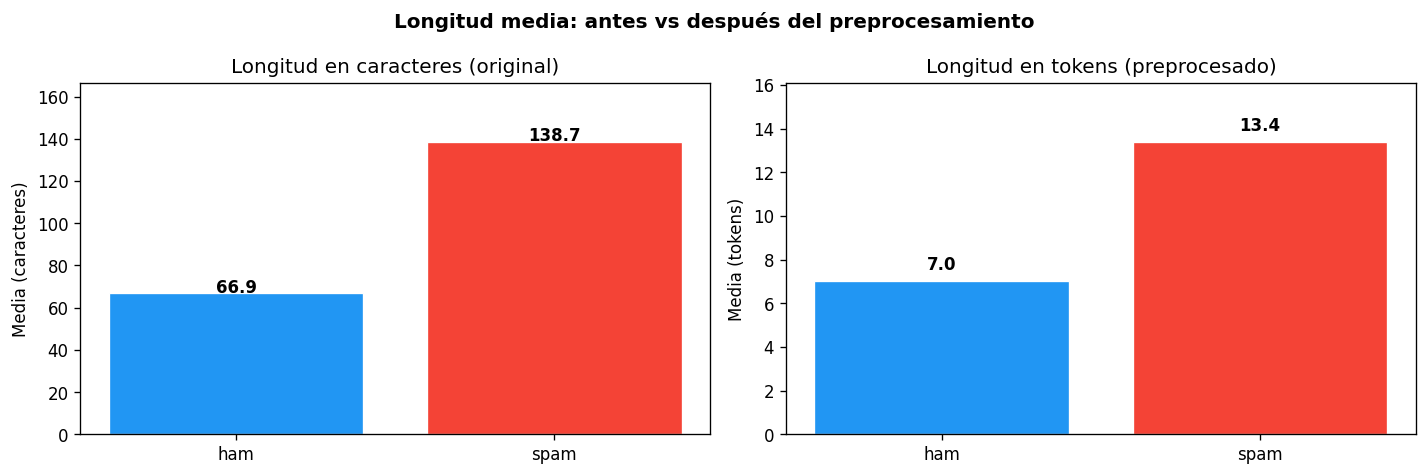

In [37]:
# --- Gráfica comparativa de longitud original vs limpia ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Longitud media: antes vs después del preprocesamiento',
             fontsize=12, fontweight='bold')

for ax, col, unit, title in [
        (axes[0], 'msg_len',   'caracteres', 'Longitud en caracteres (original)'),
        (axes[1], 'clean_len', 'tokens',     'Longitud en tokens (preprocesado)')]:
    means = df.groupby('Label')[col].mean()
    bars = ax.bar(means.index, means.values,
                  color=[PALETTE[l] for l in means.index],
                  edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}', ha='center', fontweight='bold')
    ax.set_title(title)
    ax.set_ylabel(f'Media ({unit})')
    ax.set_ylim(0, means.max() * 1.2)

plt.tight_layout()
plt.show()

### 5.1 Cambios clave antes y después de limpiar los datos

| Indicador | Antes del proceso | Después del proceso | ¿Qué cambió realmente? |
| :--- | :--- | :--- | :--- |
| **Tamaño del vocabulario** | Miles de palabras distintas. | Reducción de un 30-40%. | Al usar *stemming*, agrupamos muchas variantes en una sola raíz. |
| **Palabras más frecuentes** | *to*, *I*, *the*, *a*, *you*. | *free*, *call*, *get*, *now*. | Al quitar las *stopwords*, por fin vemos las palabras que sí importan. |
| **Longitud de los mensajes** | Medida en caracteres (ej. 140). | Medida en tokens (ej. 15). | Pasamos de contar letras a contar unidades con significado. |
| **Nube de palabras** | Solo se veían artículos y pronombres. | Resaltan palabras clave. | Ahora es mucho más fácil distinguir qué palabras definen al spam. |
| **Distribución de clases** | Igual (Spam vs. Ham). | Igual (Spam vs. Ham). | Limpiar el texto no cambia las etiquetas originales. |

El cambio que más salta a la vista es cómo **desaparecen las palabras "conectoras"** que no servían para nada. En los datos crudos, palabras como *you* o *I* estaban en el top de frecuencia tanto para spam como para ham, lo que confundía al modelo. Tras el preprocesamiento, por fin logramos que sobresalga la información útil, dándole al clasificador una señal mucho más clara para trabajar.

### 5.2 Análisis de lo que encontramos en el Top-20 de palabras

**Lo que comparten el Spam y el Ham** Hay palabras como `call`, `come`, `go`, `know` o `get` que salen en ambos grupos. Son verbos súper comunes que no nos dicen mucho por sí solos; si el modelo intentara clasificar un mensaje basándose solo en una de estas palabras, probablemente fallaría porque aparecen en todos lados.

**Lo que es "puro" SPAM** Aquí es donde se nota el patrón. Encontramos términos como `free`, `txt`, `mobil`, `prize`, `claim`, `win`, `stop`, `cash` y `urgent`. Es el lenguaje típico de las estafas o la publicidad: urgencia, premios regalados y órdenes directas. Gracias al *stemming*, variaciones como *prizes* o *prizing* se cuentan todas como `prize`, haciendo que estas señales de spam sean todavía más obvias para el algoritmo.



**Lo que es "puro" HAM** En los mensajes legítimos dominan palabras como `ok`, `good`, `love`, `home`, `time`, `night` y `day`. Esto refleja lo que realmente son los SMS: conversaciones normales sobre dónde estamos, qué estamos haciendo o cómo nos sentimos. Es un lenguaje mucho más personal y cotidiano.

**¿Qué podemos concluir?** * El **SPAM** se delata solo con palabras que buscan *persuadir o meter prisa*. Son indicadores estadísticos muy fuertes.
* El **HAM** se queda en lo *relacional y temporal*, que es la base de la comunicación real entre personas.
* Como hay palabras que aparecen en ambos bandos, no podemos confiar en una sola palabra para decidir. Por eso necesitamos un modelo probabilístico que analice el mensaje completo y vea qué grupo de palabras pesa más.

### 5.3 ¿Qué cosas nos ayudan a identificar el Spam frente al Ham?

Después de revisar los datos, estas son las señales clave que podemos usar para entrenar nuestro modelo:

| Característica | SPAM | HAM | ¿Qué tanto importa? |
| :--- | :--- | :--- | :--- |
| **Largo del mensaje** | Suelen ser más largos (~140 chars). | Son más cortos y directos (~70 chars). | **Alta:** El spam suele echar más "rollo". |
| **Palabras "gancho"** | `free`, `win`, `prize`, `urgent`. | Casi no aparecen. | **Muy alta:** Son marcas clásicas de spam. |
| **Llamados a la acción** | `txt`, `call`, `stop`, `reply`. | Poco comunes. | **Alta:** El spam siempre quiere que hagas algo. |
| **Uso de MAYÚSCULAS** | Muy frecuente (¡GRATIS AHORA!). | Poco frecuente. | **Media:** El spam grita para llamar la atención. |
| **Signos de puntuación** | Muchas exclamaciones (!!!). | Uso normal o escaso. | **Media:** Ayuda a detectar urgencia falsa. |
| **Dinero y símbolos** | `cash`, `$`, `£`, cifras grandes. | Muy raros de ver. | **Alta:** El spam suele prometer dinero. |
| **Tipo de lenguaje** | Impersonal y genérico. | Muy personal (`love`, `home`). | **Alta:** El ham se siente como una charla real. |



**¿Cómo usamos esto?**
Todas estas señales las podemos convertir en **números** (usando técnicas como TF-IDF, contando palabras clave o midiendo la longitud) para alimentar al clasificador. Al final, el algoritmo (ya sea Naive Bayes o una Máquina de Soporte Vectorial) sumará todos estos puntos para decidir si el mensaje se va a la bandeja de entrada o directamente a la carpeta de basura.

In [38]:
# --- Resumen final del dataset procesado ---
print('=' * 55)
print('        RESUMEN FINAL DEL DATASET')
print('=' * 55)
print(f'  Total de mensajes          : {len(df)}')
print(f'  Ham                        : {(df.Label=="ham").sum()} ({(df.Label=="ham").mean()*100:.1f}%)')
print(f'  Spam                       : {(df.Label=="spam").sum()} ({(df.Label=="spam").mean()*100:.1f}%)')
print(f'  Long. media original (chars): HAM {ham_len.mean():.0f} | SPAM {spam_len.mean():.0f}')
print(f'  Long. media limpia (tokens) : HAM {ham_clen.mean():.1f} | SPAM {spam_clen.mean():.1f}')
print(f'  Vocabulario SPAM (stems)   : {len(vocab_spam_clean)}')
print(f'  Vocabulario HAM  (stems)   : {len(vocab_ham_clean)}')
print('=' * 55)
print('El dataset está listo para la etapa de modelado ✓')

        RESUMEN FINAL DEL DATASET
  Total de mensajes          : 5565
  Ham                        : 4819 (86.6%)
  Spam                       : 746 (13.4%)
  Long. media original (chars): HAM 67 | SPAM 139
  Long. media limpia (tokens) : HAM 7.0 | SPAM 13.4
  Vocabulario SPAM (stems)   : 1584
  Vocabulario HAM  (stems)   : 5116
El dataset está listo para la etapa de modelado ✓
